In [1]:
# Kaggle environment file listing (standard header)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0329.png
/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0139.png
/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0572_1.png
/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0547_1.png
/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0733.png
/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0629_1.png
/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0618_1.png
/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-an

In [2]:
# CELL 1: Install Required Packages
!pip install timm -q
!pip install grad-cam -q
print("✓ All packages installed successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓ All packages installed successfully


In [3]:
# CELL 2: Import Libraries + Reproducibility Setup
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ============================================================
# REPRODUCIBILITY — must be called before ANY other operation
# ============================================================
SEED = 42

def set_seed(seed: int = 42):
    """
    Fix all random seeds for full reproducibility.
    Call this once at the very start, before data loading,
    model creation, and training.
    """
    # Python built-in random
    random.seed(seed)

    # Numpy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch GPU (current device)
    torch.cuda.manual_seed(seed)

    # PyTorch all GPUs (safe even if only 1 GPU)
    torch.cuda.manual_seed_all(seed)

    # Makes CUDA operations deterministic
    # Note: may slightly slow down training — acceptable for FYP
    torch.backends.cudnn.deterministic = True

    # Disable auto-tuning of CUDA kernels (required for determinism)
    # This overrides cudnn.benchmark = True set later in training setup
    torch.backends.cudnn.benchmark = False

    # Environment variable for extra determinism in some CUDA ops
    os.environ['PYTHONHASHSEED'] = str(seed)

    print(f"✓ All random seeds fixed to {seed}")
    print(f"  random        : seeded")
    print(f"  numpy         : seeded")
    print(f"  torch CPU     : seeded")
    print(f"  torch GPU     : seeded")
    print(f"  cudnn.deterministic : True")
    print(f"  PYTHONHASHSEED      : {seed}")

# Call immediately
set_seed(SEED)

# ── Device setup ─────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Available GPUs: {torch.cuda.device_count()}")

✓ All random seeds fixed to 42
  random        : seeded
  numpy         : seeded
  torch CPU     : seeded
  torch GPU     : seeded
  cudnn.deterministic : True
  PYTHONHASHSEED      : 42

Using device: cuda
GPU: Tesla T4
Available GPUs: 2


In [4]:
# CELL 3: Configuration and Hyperparameters
# ============================================================
# V2.0 Changes vs V1.3:
#   - IMG_SIZE        : 224  →  320  (captures finer TB detail)
#   - LEARNING_RATE   : 1e-4 →  3e-5 (gentler convergence)
#   - DROPOUT         : 0.1  →  0.25 (reduce overfitting)
#   - WEIGHT_DECAY    : 1e-5 →  1e-4 (stronger regularisation)
#   - Backbone        : ResNet50 → DenseNet121 (chest-X-ray optimised)
#   - Scheduler       : ReduceLROnPlateau → CosineAnnealingWarmRestarts
#   - Loss            : CrossEntropyLoss → CrossEntropyLoss(label_smoothing=0.1)
#   - Augmentation    : added GaussianBlur + RandomErasing + Mixup
#   - DataLoader      : added WeightedRandomSampler (full dataset support)
# ============================================================

class Config:
    DATA_PATH = '/kaggle/input/datasets/mohammadjc/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen'

    IMG_SIZE   = 320          # ← was 224
    BATCH_SIZE = 16           # ← was 32 (reduced to fit 320px in GPU memory)

    NUM_CLASSES              = 2
    EMBEDDING_DIM            = 768
    NUM_HEADS                = 8
    NUM_TRANSFORMER_BLOCKS   = 4
    MLP_DIM                  = 2048
    DROPOUT                  = 0.20   #0.25  <- # ← was 0.1

    EPOCHS                   = 60     # ← was 50 (cosine scheduler benefits from more epochs)
    LEARNING_RATE            = 5e-5   #3e-5 <-  # ← was 1e-4
    WEIGHT_DECAY             = 5e-5       #1e-4 <-  # ← was 1e-5
    EARLY_STOPPING_PATIENCE  = 12     # ← was 10

    # Cosine annealing
    COSINE_T0    = 15   #10 <-  # restart every 10 epochs
    COSINE_TMULT = 2    # double period after each restart
    COSINE_ETAMIN = 1e-7

    # Mixup
    MIXUP_ALPHA  = 0.2
    MIXUP_PROB   = 0.3  #0.5 <- # apply mixup to 50% of batches

    TRAIN_SPLIT  = 0.70
    VAL_SPLIT    = 0.15
    TEST_SPLIT   = 0.15

    CLAHE_CLIP_LIMIT = 2.0
    CLAHE_TILE_GRID  = (8, 8)

    CLASS_NAMES  = ['Normal', 'TB']

config = Config()
print("✓ V2.0 Configuration loaded")
print(f"  IMG_SIZE      : {config.IMG_SIZE}")
print(f"  BATCH_SIZE    : {config.BATCH_SIZE}")
print(f"  LEARNING_RATE : {config.LEARNING_RATE}")
print(f"  DROPOUT       : {config.DROPOUT}")
print(f"  WEIGHT_DECAY  : {config.WEIGHT_DECAY}")
print(f"  CLAHE         : clip={config.CLAHE_CLIP_LIMIT}, grid={config.CLAHE_TILE_GRID}")

✓ V2.0 Configuration loaded
  IMG_SIZE      : 320
  BATCH_SIZE    : 16
  LEARNING_RATE : 5e-05
  DROPOUT       : 0.2
  WEIGHT_DECAY  : 5e-05
  CLAHE         : clip=2.0, grid=(8, 8)


In [5]:
# CELL 4: CLAHE Preprocessor
# ============================================================
# FLASK CONTRACT — this class is copy-pasted verbatim into app.py.
# Any change here MUST be mirrored in app.py → CLAHEPreprocessor.
# ============================================================

class CLAHEPreprocessor:
    """
    Lightweight CLAHE-based preprocessing for chest X-rays.
    Steps:
        1. Load image (BGR -> RGB)
        2. Convert to LAB colour space
        3. Apply CLAHE on the L (luminance) channel only
        4. Reconstruct RGB image
        5. Resize to model input size

    Flask note: apply_clahe() returns both original and enhanced arrays
    so the UI can display both.
    """

    def __init__(self, img_size=320, clip_limit=2.0, tile_grid=(8, 8)):
        self.img_size = img_size
        self.clahe    = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid
        )

    def apply_clahe(self, image_rgb: np.ndarray):
        """
        Apply CLAHE to an RGB numpy array.
        Returns (original_rgb, enhanced_rgb) — both uint8 at original resolution.
        """
        original_rgb = image_rgb.copy()
        lab          = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        l, a, b      = cv2.split(lab)
        l_clahe      = self.clahe.apply(l)
        lab_clahe    = cv2.merge([l_clahe, a, b])
        enhanced     = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        return original_rgb, enhanced

    def preprocess(self, image_path: str):
        """
        Load, CLAHE-enhance and resize an image from file path.
        Returns dict:
            'original'  — uint8 RGB at original resolution
            'enhanced'  — uint8 RGB at original resolution
            'pil_image' — PIL Image of enhanced, resized to IMG_SIZE (fed to transforms)
        """
        img_bgr   = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        original_rgb, enhanced_rgb = self.apply_clahe(image_rgb)
        enhanced_resized = cv2.resize(enhanced_rgb, (self.img_size, self.img_size))
        pil_image        = Image.fromarray(enhanced_resized)
        return {
            'original'  : original_rgb,
            'enhanced'  : enhanced_rgb,
            'pil_image' : pil_image
        }

    def preprocess_array(self, image_rgb: np.ndarray):
        """
        Same as preprocess() but accepts a numpy RGB array directly.
        Used by Flask (image comes from file upload, not file path).
        """
        original_rgb, enhanced_rgb = self.apply_clahe(image_rgb)
        enhanced_resized = cv2.resize(enhanced_rgb, (self.img_size, self.img_size))
        pil_image        = Image.fromarray(enhanced_resized)
        return {
            'original'  : original_rgb,
            'enhanced'  : enhanced_rgb,
            'pil_image' : pil_image
        }

print("✓ CLAHEPreprocessor defined (V2.0 — includes preprocess_array for Flask)")

✓ CLAHEPreprocessor defined (V2.0 — includes preprocess_array for Flask)


In [6]:
# CELL 5: Dataset Class with WeightedRandomSampler support

class TBXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths  = image_paths
        self.labels       = labels
        self.transform    = transform
        self.preprocessor = CLAHEPreprocessor(
            img_size   = config.IMG_SIZE,
            clip_limit = config.CLAHE_CLIP_LIMIT,
            tile_grid  = config.CLAHE_TILE_GRID
        )
        print(f"✓ Dataset initialised — {len(image_paths)} images | CLAHE ON")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        result  = self.preprocessor.preprocess(self.image_paths[idx])
        pil_img = result['pil_image']
        label   = self.labels[idx]
        if self.transform:
            pil_img = self.transform(pil_img)
        return pil_img, label

print("✓ TBXrayDataset defined")

✓ TBXrayDataset defined


In [7]:
# CELL 6: Data Augmentation and Transforms
# V2.0 additions: GaussianBlur (scan quality variation) + RandomErasing (artifact robustness)

train_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),  # ← NEW
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),                       # ← NEW
])

val_test_transforms = transforms.Compose([
    transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✓ V2.0 Transforms defined")
print("  Train : augmentation ON  | CLAHE ON | GaussianBlur ON | RandomErasing ON")
print("  Val   : augmentation OFF | CLAHE ON")

✓ V2.0 Transforms defined
  Train : augmentation ON  | CLAHE ON | GaussianBlur ON | RandomErasing ON
  Val   : augmentation OFF | CLAHE ON


In [8]:
# CELL 7: Load and Split Data
# Uses full dataset — WeightedRandomSampler in DataLoader handles balance.

def load_data(data_path):
    image_paths, labels = [], []
    tb_folder = os.path.join(data_path, 'TB')
    if os.path.exists(tb_folder):
        for f in sorted(os.listdir(tb_folder)):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(tb_folder, f))
                labels.append(1)
    normal_folder = os.path.join(data_path, 'Normal')
    if os.path.exists(normal_folder):
        for f in sorted(os.listdir(normal_folder)):
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(normal_folder, f))
                labels.append(0)
    return np.array(image_paths), np.array(labels)

print("Loading data...")
image_paths, labels = load_data(config.DATA_PATH)

print(f"  Total  : {len(image_paths)}")
print(f"  Normal : {np.sum(labels == 0)}")
print(f"  TB     : {np.sum(labels == 1)}")

X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths, labels, test_size=config.TEST_SPLIT, random_state=42, stratify=labels
)
val_size = config.VAL_SPLIT / (config.TRAIN_SPLIT + config.VAL_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size, random_state=42, stratify=y_temp
)

print(f"\nData Split:")
print(f"  Train : {len(X_train)}  (Normal: {np.sum(y_train==0)}, TB: {np.sum(y_train==1)})")
print(f"  Val   : {len(X_val)}   (Normal: {np.sum(y_val==0)},  TB: {np.sum(y_val==1)})")
print(f"  Test  : {len(X_test)}  (Normal: {np.sum(y_test==0)},  TB: {np.sum(y_test==1)})")

Loading data...
  Total  : 2388
  Normal : 1194
  TB     : 1194

Data Split:
  Train : 1670  (Normal: 835, TB: 835)
  Val   : 359   (Normal: 179,  TB: 180)
  Test  : 359  (Normal: 180,  TB: 179)


CLAHE ENHANCEMENT PREVIEW


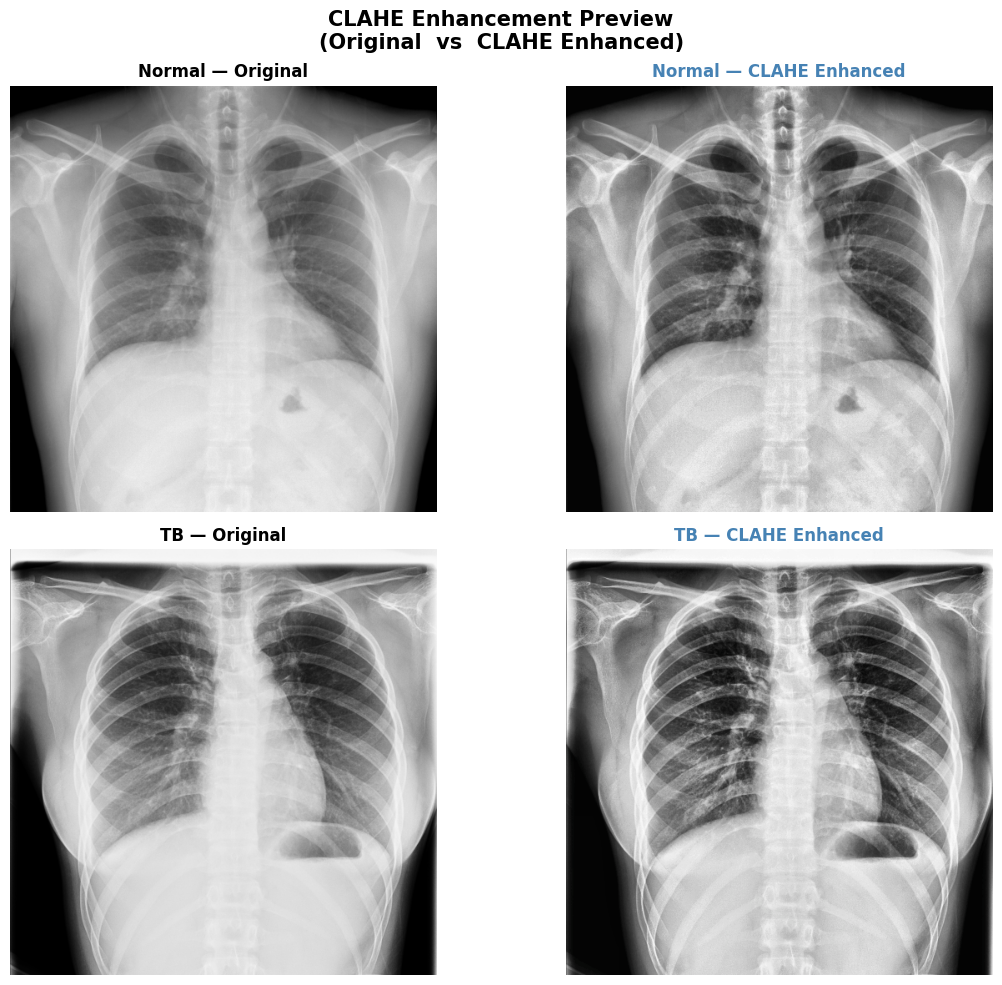

✓ CLAHE preview saved


In [9]:
# CELL 8: CLAHE Enhancement Preview

print("=" * 60)
print("CLAHE ENHANCEMENT PREVIEW")
print("=" * 60)

preview_preprocessor = CLAHEPreprocessor(
    img_size   = config.IMG_SIZE,
    clip_limit = config.CLAHE_CLIP_LIMIT,
    tile_grid  = config.CLAHE_TILE_GRID
)

tb_paths     = X_train[y_train == 1]
normal_paths = X_train[y_train == 0]
sample_tb     = tb_paths[0]
sample_normal = normal_paths[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("CLAHE Enhancement Preview\n(Original  vs  CLAHE Enhanced)",
             fontsize=15, fontweight='bold')

for row, (img_path, class_name) in enumerate(
        [(sample_normal, 'Normal'), (sample_tb, 'TB')]):
    result = preview_preprocessor.preprocess(img_path)
    orig   = result['original']
    enh    = result['enhanced']

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"{class_name} — Original", fontsize=12, fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(enh)
    axes[row, 1].set_title(f"{class_name} — CLAHE Enhanced", fontsize=12,
                            fontweight='bold', color='steelblue')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig('clahe_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ CLAHE preview saved")

In [10]:
# CELL 9: Model Architecture — Patch Embedding
# DenseNet121 outputs 1024 channels → PatchEmbedding accepts 1024 (was 2048 for ResNet50)

class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=1024, embed_dim=768, patch_size=1):  # ← in_channels: 2048→1024
        super().__init__()
        self.projection = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )

    def forward(self, x):
        x = self.projection(x)   # (B, embed_dim, H', W')
        x = x.flatten(2)          # (B, embed_dim, N)
        x = x.transpose(1, 2)     # (B, N, embed_dim)
        return x

print("✓ PatchEmbedding defined (in_channels=1024 for DenseNet121)")

✓ PatchEmbedding defined (in_channels=1024 for DenseNet121)


In [11]:
# CELL 10: Model Architecture — Transformer Block (unchanged from V1.3)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.mlp(x))
        return x

print("✓ TransformerBlock defined")

✓ TransformerBlock defined


In [12]:
# CELL 11: Complete Hybrid Model — V2.0 (DenseNet121 backbone)
# ============================================================
# Key changes from V1.3:
#   - Backbone: ResNet50 → DenseNet121
#     DenseNet121 is the standard backbone for chest X-ray pathology detection.
#     It was used in the original CheXNet paper (Rajpurkar et al. 2017) and
#     consistently outperforms ResNet50 on radiograph datasets.
#   - PatchEmbedding in_channels: 2048 → 1024 (DenseNet121 final feature dim)
#   - num_patches updated: DenseNet121 with 320px input gives 10x10=100 patches
#   - Unfreezing strategy updated to match DenseNet layer naming
# ============================================================

class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes=2, embedding_dim=768, num_heads=8,
                 num_blocks=4, mlp_dim=2048, dropout=0.25):
        super().__init__()

        # ── Backbone: DenseNet121 pretrained on ImageNet ──────────────
        from torchvision.models import DenseNet121_Weights
        densenet        = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        # features outputs (B, 1024, H/32, W/32) — for 320px input → (B, 1024, 10, 10)
        self.backbone   = densenet.features   # keeps BatchNorm + all dense blocks
        self.relu_after = nn.ReLU(inplace=True)

        # Freeze early layers (denseblock1 + transition1), fine-tune the rest
        freeze_names = ['conv0', 'norm0', 'denseblock1', 'transition1']
        for name, param in self.backbone.named_parameters():
            if any(name.startswith(fn) for fn in freeze_names):
                param.requires_grad = False

        # ── Patch Embedding ──────────────────────────────────────────
        # DenseNet121 → 1024 channels; 320px input → 10×10 = 100 patches
        self.patch_embed = PatchEmbedding(
            in_channels=1024,
            embed_dim=embedding_dim,
            patch_size=1
        )
        self.num_patches = 100              # 10×10 for 320px input
        self.pos_embed   = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, embedding_dim)
        )
        self.cls_token   = nn.Parameter(
            torch.zeros(1, 1, embedding_dim)
        )

        # ── Transformer Encoder ──────────────────────────────────────
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embedding_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_blocks)
        ])

        # ── Classification Head ──────────────────────────────────────
        self.norm = nn.LayerNorm(embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(embedding_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

        # Initialise positional embedding and class token
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.shape[0]

        # CNN feature extraction
        x = self.backbone(x)          # (B, 1024, 10, 10) for 320px input
        x = self.relu_after(x)         # DenseNet needs explicit ReLU after features

        # Patch embedding
        x = self.patch_embed(x)        # (B, 100, 768)

        # Add class token + positional embedding
        cls = self.cls_token.expand(B, -1, -1)   # (B, 1, 768)
        x   = torch.cat([cls, x], dim=1)          # (B, 101, 768)
        x   = x + self.pos_embed

        # Transformer blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Classify using CLS token
        x = self.norm(x[:, 0])   # (B, 768)
        return self.head(x)       # (B, num_classes)

# Initialise model
model = HybridCNNTransformer(
    num_classes   = config.NUM_CLASSES,
    embedding_dim = config.EMBEDDING_DIM,
    num_heads     = config.NUM_HEADS,
    num_blocks    = config.NUM_TRANSFORMER_BLOCKS,
    mlp_dim       = config.MLP_DIM,
    dropout       = config.DROPOUT
)

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✓ V2.0 Model created and moved to {device}")
print(f"  Backbone      : DenseNet121 (was ResNet50)")
print(f"  Feature map   : (B, 1024, 10, 10) for {config.IMG_SIZE}px input")
print(f"  Num patches   : {model.num_patches}  (was 49)")
print(f"  Total params  : {total_params:,}")
print(f"  Trainable     : {trainable_params:,}")
print(f"  Frozen        : {total_params - trainable_params:,}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 166MB/s]



✓ V2.0 Model created and moved to cuda
  Backbone      : DenseNet121 (was ResNet50)
  Feature map   : (B, 1024, 10, 10) for 320px input
  Num patches   : 100  (was 49)
  Total params  : 30,271,618
  Trainable     : 29,893,762
  Frozen        : 377,856


In [13]:
# CELL 12: Create Datasets and DataLoaders (GPU Optimised)
# V2.0: WeightedRandomSampler on train_loader ensures balanced sampling
#       even when using the full unbalanced dataset.

# ── Seeded worker initialiser for reproducible augmentation ──
def seed_worker(worker_id):
    """Seed each DataLoader worker process individually.
    Without this, each worker has an independent random state,
    making augmentation non-reproducible across runs."""
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

# Generator for reproducible sampler and loader shuffling
g = torch.Generator()
g.manual_seed(SEED)

train_dataset = TBXrayDataset(X_train, y_train, transform=train_transforms)
val_dataset   = TBXrayDataset(X_val,   y_val,   transform=val_test_transforms)
test_dataset  = TBXrayDataset(X_test,  y_test,  transform=val_test_transforms)

# ── WeightedRandomSampler for balanced training batches ──────
class_counts   = np.bincount(y_train)           # [num_normal, num_tb]
class_weights  = 1.0 / class_counts             # inverse frequency
sample_weights = torch.tensor(
    [class_weights[label] for label in y_train], dtype=torch.float
)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=g          # ← seeds the sampler for reproducible sampling order
)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE,
    sampler=sampler,                # ← replaces shuffle=True
    num_workers=4, pin_memory=True, persistent_workers=True,
    worker_init_fn=seed_worker,     # ← seeds each worker process
    generator=g                     # ← seeds the loader's internal shuffling
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True,
    worker_init_fn=seed_worker      # ← seeds each worker process
)
test_loader = DataLoader(
    test_dataset, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True,
    worker_init_fn=seed_worker      # ← seeds each worker process
)

print("✓ V2.0 DataLoaders created")
print(f"  Train batches : {len(train_loader)}  (WeightedRandomSampler ON)")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")
print(f"  Class weights : Normal={class_weights[0]:.4f}, TB={class_weights[1]:.4f}")
print(f"  Reproducibility : seed_worker + Generator(SEED={SEED}) ON")

✓ Dataset initialised — 1670 images | CLAHE ON
✓ Dataset initialised — 359 images | CLAHE ON
✓ Dataset initialised — 359 images | CLAHE ON
✓ V2.0 DataLoaders created
  Train batches : 105  (WeightedRandomSampler ON)
  Val batches   : 23
  Test batches  : 23
  Class weights : Normal=0.0012, TB=0.0012
  Reproducibility : seed_worker + Generator(SEED=42) ON


In [14]:
# CELL 13: Training Setup
# V2.0 changes:
#   - Loss: CrossEntropyLoss → CrossEntropyLoss(label_smoothing=0.1)
#   - Scheduler: ReduceLROnPlateau → CosineAnnealingWarmRestarts

# Loss with label smoothing (handles annotation noise across 3 merged datasets)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)  #0.1 <- # ← was CrossEntropyLoss()

# Optimizer — only trainable parameters
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Cosine Annealing with Warm Restarts
# T_0=10: first restart at epoch 10; T_mult=2: each cycle doubles in length
# This helps escape local minima and finds sharper optima vs plateau scheduling.
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=config.COSINE_T0,
    T_mult=config.COSINE_TMULT,
    eta_min=config.COSINE_ETAMIN
)

# GPU optimisations
# NOTE: cudnn.benchmark is intentionally set to False here.
# set_seed() in Cell 2 sets deterministic=True + benchmark=False for
# full reproducibility. benchmark=True would auto-tune CUDA kernels and
# break determinism — so it is disabled despite the small speed trade-off.
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True   # ← ensures reproducible CUDA ops
    torch.backends.cudnn.benchmark     = False  # ← was True; disabled for reproducibility
    torch.backends.cudnn.enabled       = True
    print("✓ GPU enabled (deterministic mode — benchmark=False for reproducibility)")

print("\n✓ V2.0 Training setup complete")
print(f"  Loss      : CrossEntropyLoss(label_smoothing=0.05)")  # ← fixed: was 0.1
print(f"  Optimizer : AdamW (lr={config.LEARNING_RATE}, wd={config.WEIGHT_DECAY})")
print(f"  Scheduler : CosineAnnealingWarmRestarts (T0={config.COSINE_T0}, Tmult={config.COSINE_TMULT})")
print(f"  Device    : {device}")
print(f"  Seed      : {SEED} (deterministic=True, benchmark=False)")

✓ GPU enabled (deterministic mode — benchmark=False for reproducibility)

✓ V2.0 Training setup complete
  Loss      : CrossEntropyLoss(label_smoothing=0.05)
  Optimizer : AdamW (lr=5e-05, wd=5e-05)
  Scheduler : CosineAnnealingWarmRestarts (T0=15, Tmult=2)
  Device    : cuda
  Seed      : 42 (deterministic=True, benchmark=False)


In [15]:
# CELL 14: Training and Validation Functions with Mixup
# V2.0: Mixup augmentation added to train_epoch.

def mixup_data(x, y, alpha=0.2):
    """Apply Mixup augmentation to a batch."""
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx   = torch.randperm(x.size(0), device=x.device)
    mixed = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute mixed loss for Mixup."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_epoch(model, dataloader, criterion, optimizer, device,
                mixup_alpha=0.2, mixup_prob=0.5):
    """Train for one epoch with optional Mixup."""
    model.train()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Apply Mixup with probability mixup_prob
        use_mixup = (np.random.random() < mixup_prob)
        if use_mixup:
            mixed_images, y_a, y_b, lam = mixup_data(images, labels, alpha=mixup_alpha)
            outputs = model(mixed_images)
            loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)
        else:
            outputs = model(images)
            loss    = criterion(outputs, labels)

        loss.backward()
        # Gradient clipping for stable training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        probs  = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].detach().cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(dataloader)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    epoch_auc  = roc_auc_score(all_labels, all_probs)
    return epoch_loss, epoch_acc, epoch_auc


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch — no Mixup, no augmentation."""
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item()
            probs  = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(dataloader)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    epoch_auc  = roc_auc_score(all_labels, all_probs)
    return epoch_loss, epoch_acc, epoch_auc

print("✓ V2.0 Training functions defined (Mixup + gradient clipping added)")

✓ V2.0 Training functions defined (Mixup + gradient clipping added)


In [16]:
# CELL 15: Training Loop
# V2.0: CosineAnnealingWarmRestarts scheduler called per-epoch.

history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_auc'  : [],
    'lr'        : []
}

best_val_auc    = 0.0
patience_counter = 0

print("\n" + "="*60)
print("STARTING TRAINING  (V2.0)")
print("="*60)

for epoch in range(config.EPOCHS):
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch+1}/{config.EPOCHS}  |  LR: {current_lr:.2e}")
    print("-" * 60)

    train_loss, train_acc, train_auc = train_epoch(
        model, train_loader, criterion, optimizer, device,
        mixup_alpha=config.MIXUP_ALPHA, mixup_prob=config.MIXUP_PROB
    )
    val_loss, val_acc, val_auc = validate_epoch(
        model, val_loader, criterion, device
    )

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train  Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | AUC: {train_auc:.4f}")
    print(f"  Val    Loss: {val_loss:.4f}   | Acc: {val_acc:.4f}   | AUC: {val_auc:.4f}")

    # Step cosine scheduler every epoch
    scheduler.step(epoch)

    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ New best model saved! (AUC: {best_val_auc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= config.EARLY_STOPPING_PATIENCE:
        print(f"\n✗ Early stopping triggered after {epoch+1} epochs")
        break

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Best Validation AUC: {best_val_auc:.4f}")


STARTING TRAINING  (V2.0)

Epoch 1/60  |  LR: 5.00e-05
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:24<00:00,  1.05s/it, loss=0.1293]



Epoch 1 Summary:
  Train  Loss: 0.4873 | Acc: 0.7485 | AUC: 0.8146
  Val    Loss: 0.3625   | Acc: 0.8719   | AUC: 0.9718
  ✓ New best model saved! (AUC: 0.9718)

Epoch 2/60  |  LR: 5.00e-05
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:22<00:00,  1.00it/s, loss=0.5992]



Epoch 2 Summary:
  Train  Loss: 0.3596 | Acc: 0.8383 | AUC: 0.8917
  Val    Loss: 0.4022   | Acc: 0.8747   | AUC: 0.9762
  ✓ New best model saved! (AUC: 0.9762)

Epoch 3/60  |  LR: 4.95e-05
------------------------------------------------------------


...


Epoch 39 Summary:
  Train  Loss: 0.1827 | Acc: 0.9102 | AUC: 0.9247
  Val    Loss: 0.3024   | Acc: 0.9331   | AUC: 0.9880

Epoch 40/60  |  LR: 6.51e-06
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:24<00:00,  1.06s/it, loss=0.1173]



Epoch 40 Summary:
  Train  Loss: 0.1617 | Acc: 0.9162 | AUC: 0.9179
  Val    Loss: 0.2936   | Acc: 0.9359   | AUC: 0.9887

Epoch 41/60  |  LR: 4.87e-06
------------------------------------------------------------


Validation: 100%|██████████| 23/23 [00:23<00:00,  1.03s/it, loss=0.1172]


Epoch 41 Summary:
  Train  Loss: 0.1590 | Acc: 0.9240 | AUC: 0.9329
  Val    Loss: 0.2916   | Acc: 0.9387   | AUC: 0.9889

✗ Early stopping triggered after 41 epochs

TRAINING COMPLETE
Best Validation AUC: 0.9923


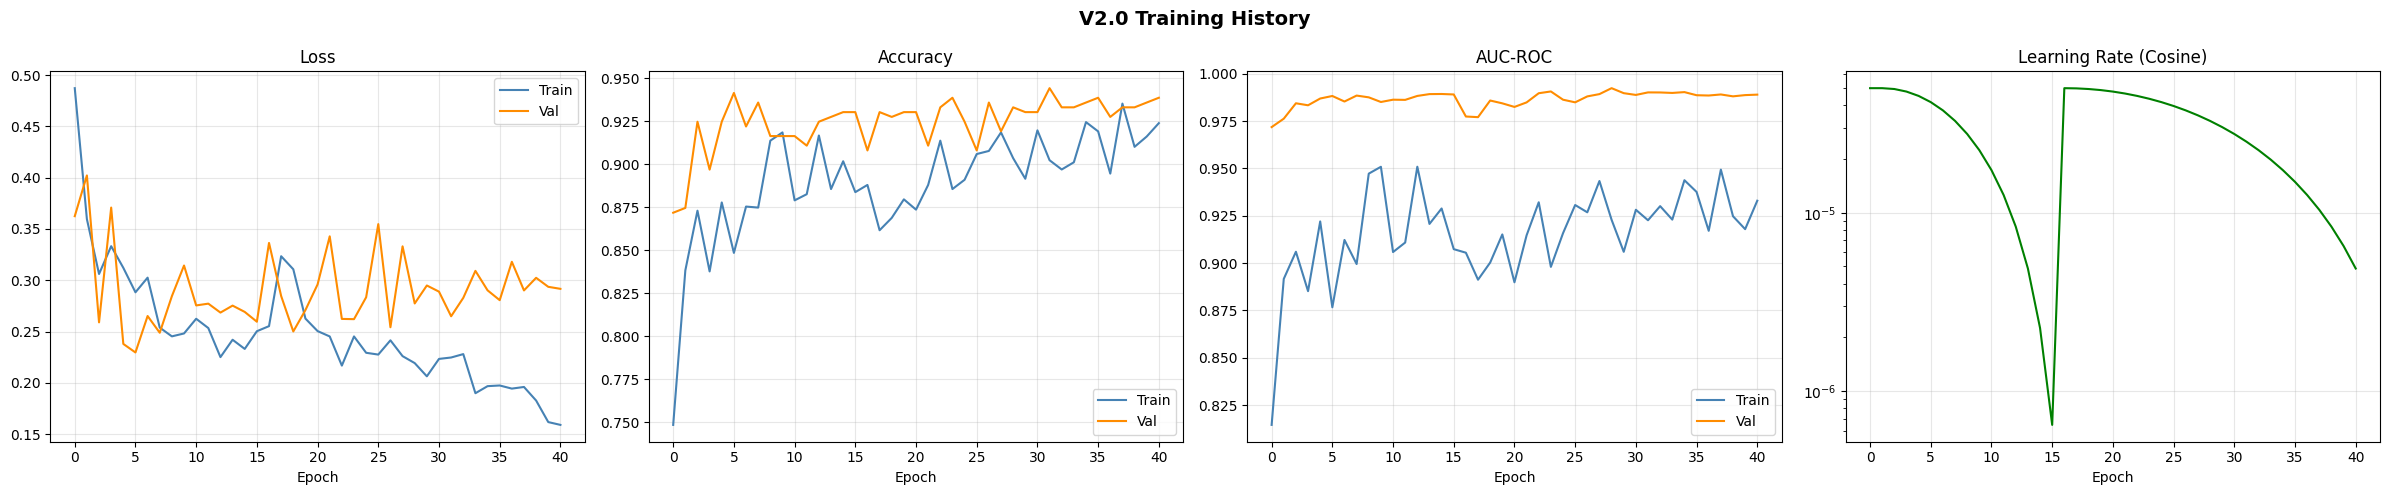

✓ Training history saved


In [17]:
# CELL 16: Plot Training History (includes LR curve)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle('V2.0 Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='darkorange')
axes[0].set_title('Loss');  axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val',   color='darkorange')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history['train_auc'], label='Train', color='steelblue')
axes[2].plot(history['val_auc'],   label='Val',   color='darkorange')
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

# Learning Rate
axes[3].plot(history['lr'], color='green')
axes[3].set_title('Learning Rate (Cosine)'); axes[3].set_xlabel('Epoch')
axes[3].set_yscale('log'); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training history saved")


TEST SET EVALUATION


Validation: 100%|██████████| 23/23 [00:23<00:00,  1.01s/it, loss=0.1181]



Test Results:
  Test Loss     : 0.2322
  Test Accuracy : 0.9554
  Test AUC      : 0.9926

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.96       180
          TB       0.95      0.96      0.96       179

    accuracy                           0.96       359
   macro avg       0.96      0.96      0.96       359
weighted avg       0.96      0.96      0.96       359



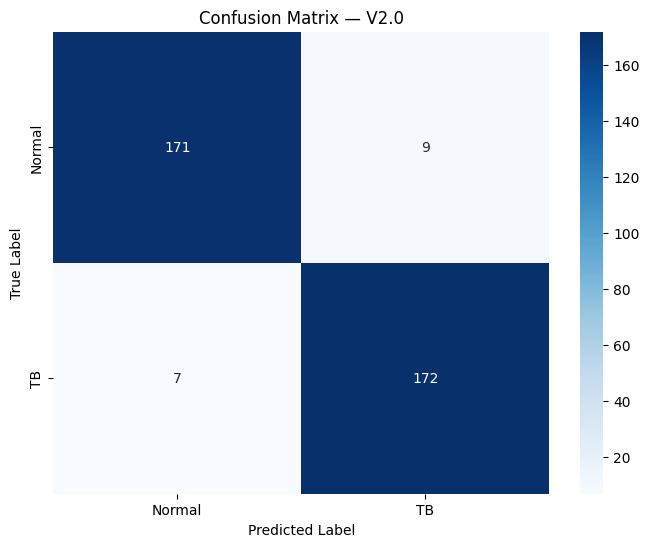

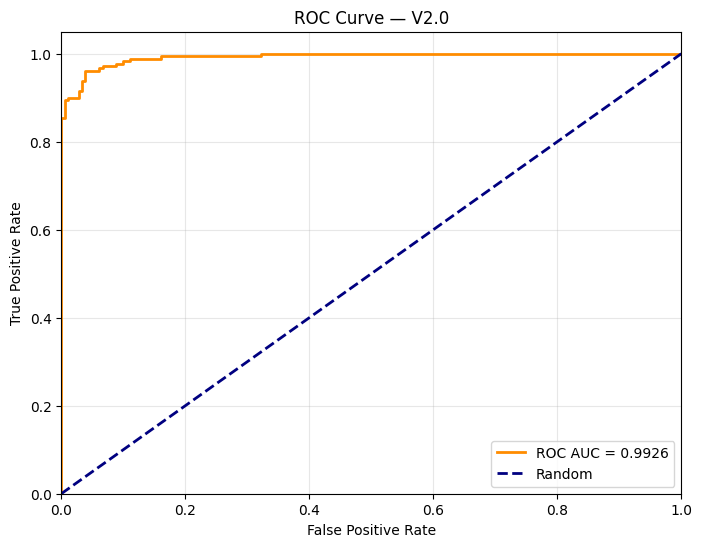

✓ Evaluation plots saved


In [18]:
# CELL 17: Load Best Model and Evaluate on Test Set

model.load_state_dict(torch.load('best_model.pth'))
model.eval()

print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

test_loss, test_acc, test_auc = validate_epoch(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  Test AUC      : {test_auc:.4f}")

# Detailed predictions
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=config.CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=config.CLASS_NAMES,
            yticklabels=config.CLASS_NAMES)
plt.title('Confusion Matrix — V2.0')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — V2.0'); plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Evaluation plots saved")


GRAD-CAM INTERPRETABILITY VISUALISATION  (V2.0)


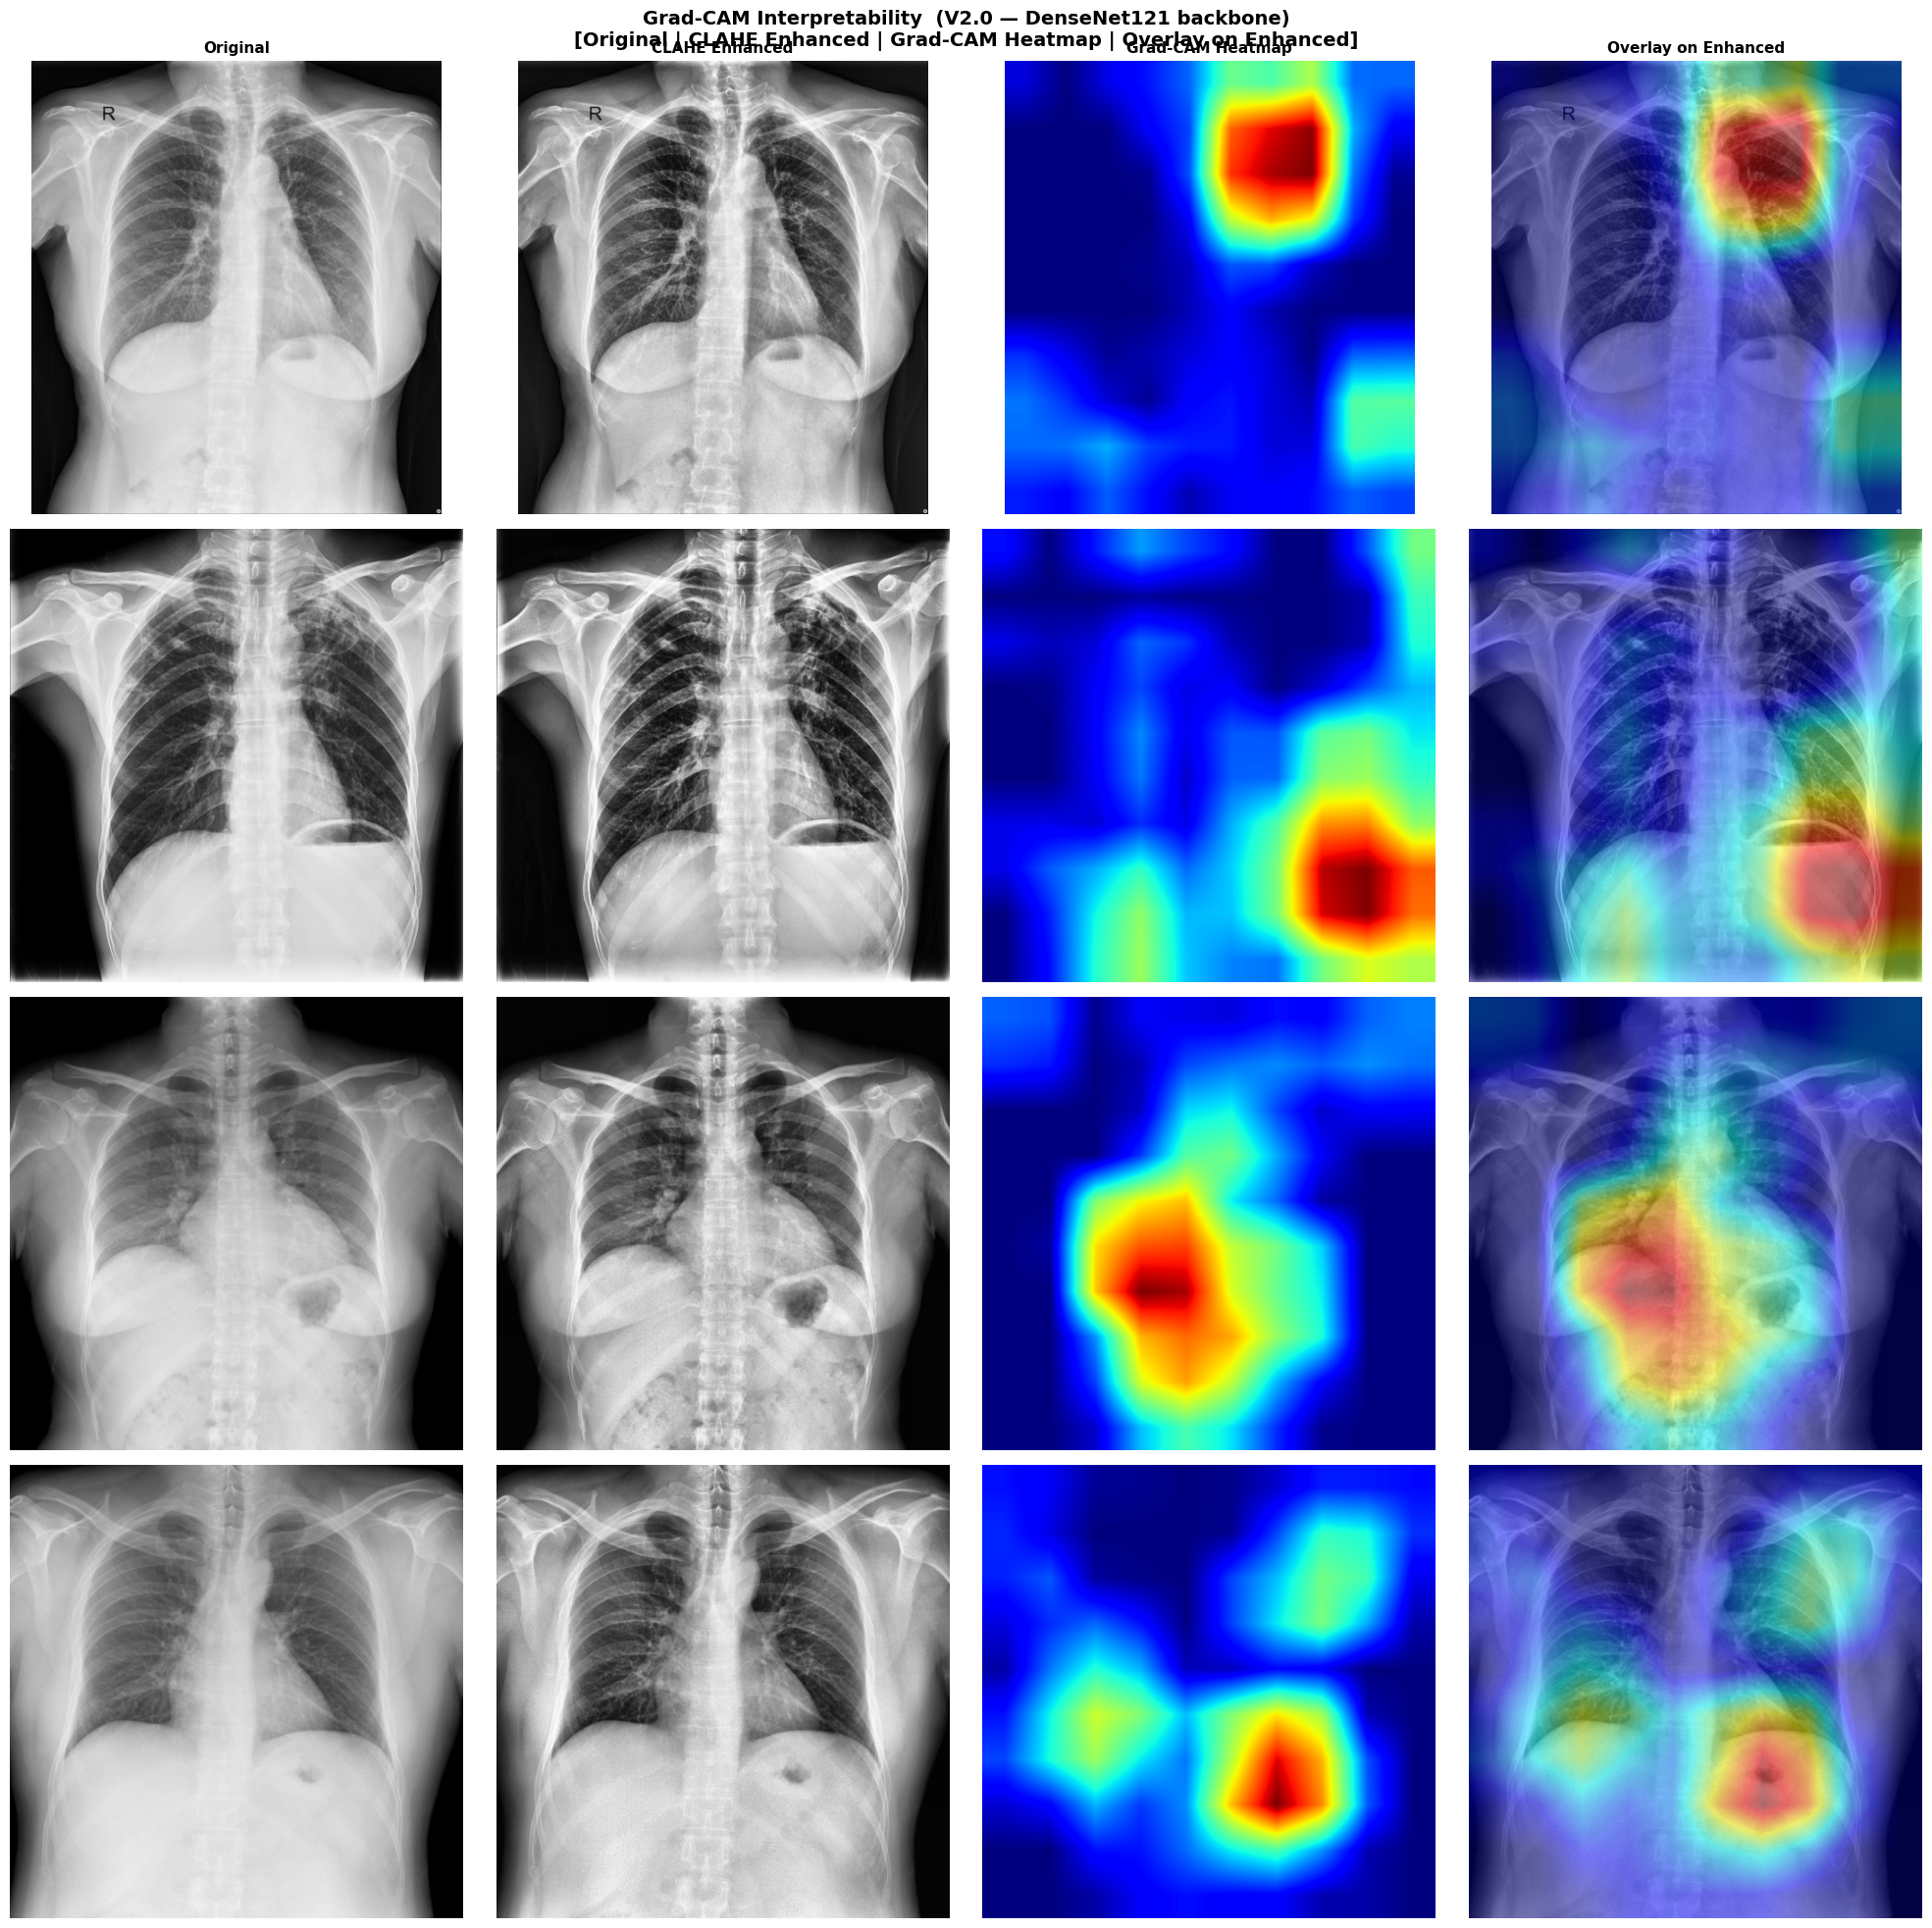

✓ Grad-CAM saved as 'gradcam_interpretability.png'
  Samples shown : 4 (2 TB + 2 Normal)


In [19]:
# CELL 18: Grad-CAM Interpretability — 4 panels per image
# V2.0: target layer updated for DenseNet121 backbone.
# Shows 2 TB + 2 Normal samples with:
#   Original | CLAHE Enhanced | Grad-CAM Heatmap | Overlay on Enhanced
# Each row label shows: True class | Predicted class | Confidence | Normal% | TB%

print("\n" + "=" * 60)
print("GRAD-CAM INTERPRETABILITY VISUALISATION  (V2.0)")
print("=" * 60)

# Fix random state so same images are selected every run
np.random.seed(SEED)   # ← added: reproducible sample selection

NUM_SAMPLES = 4        # 2 TB + 2 Normal

# DenseNet121 target layer: last conv in norm5 (final dense block output)
TARGET_LAYER = [model.backbone.norm5]

gradcam_engine   = GradCAM(model=model, target_layers=TARGET_LAYER)
viz_preprocessor = CLAHEPreprocessor(
    img_size   = config.IMG_SIZE,
    clip_limit = config.CLAHE_CLIP_LIMIT,
    tile_grid  = config.CLAHE_TILE_GRID
)

tb_idx     = np.where(y_test == 1)[0]
normal_idx = np.where(y_test == 0)[0]
sample_indices = np.concatenate([
    np.random.choice(tb_idx,     min(NUM_SAMPLES // 2, len(tb_idx)),     replace=False),
    np.random.choice(normal_idx, min(NUM_SAMPLES // 2, len(normal_idx)), replace=False)
])

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(20, 5 * len(sample_indices)))
fig.suptitle("Grad-CAM Interpretability  (V2.0 — DenseNet121 backbone)\n"
             "[Original | CLAHE Enhanced | Grad-CAM Heatmap | Overlay on Enhanced]",
             fontsize=14, fontweight='bold')

col_titles = ["Original", "CLAHE Enhanced", "Grad-CAM Heatmap", "Overlay on Enhanced"]
model.eval()

for row, idx in enumerate(sample_indices):
    img_path   = X_test[idx]
    true_label = y_test[idx]

    result       = viz_preprocessor.preprocess(img_path)
    original_rgb = result['original']
    enhanced_rgb = result['enhanced']
    pil_image    = result['pil_image']

    input_tensor = val_test_transforms(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        probs  = torch.softmax(output, dim=1)[0].cpu().numpy()

    pred_class   = int(np.argmax(probs))
    confidence   = float(probs[pred_class])
    uncertainty  = float(-np.sum(probs * np.log(probs + 1e-10)))
    normal_prob  = float(probs[0])   # ← added: explicit Normal probability
    tb_prob      = float(probs[1])   # ← added: explicit TB probability
    correct      = "✓" if pred_class == true_label else "✗"

    targets       = [ClassifierOutputTarget(pred_class)]
    grayscale_cam = gradcam_engine(input_tensor=input_tensor, targets=targets)[0]
    h, w          = enhanced_rgb.shape[:2]
    cam_resized   = cv2.resize(grayscale_cam, (w, h))
    enhanced_norm = enhanced_rgb.astype(np.float32) / 255.0
    overlay       = show_cam_on_image(enhanced_norm, cam_resized, use_rgb=True)

    # ← updated: row label now shows both class scores separately
    row_label = (f"True: {config.CLASS_NAMES[true_label]}  |  "
                 f"Pred: {config.CLASS_NAMES[pred_class]}  {correct}\n"
                 f"Confidence: {confidence:.1%}  |  Uncertainty: {uncertainty:.3f}\n"
                 f"Normal: {normal_prob:.1%}  |  TB: {tb_prob:.1%}")

    for col, (img, cmap, col_title) in enumerate(zip(
            [original_rgb, enhanced_rgb, cam_resized, overlay],
            [None, None, 'jet', None], col_titles)):
        ax = axes[row, col] if len(sample_indices) > 1 else axes[col]
        ax.imshow(img, cmap=cmap)
        if row == 0:
            ax.set_title(col_title, fontsize=11, fontweight='bold', pad=6)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(row_label, fontsize=9, rotation=0, labelpad=180, va='center')

plt.tight_layout()
plt.savefig('gradcam_interpretability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Grad-CAM saved as 'gradcam_interpretability.png'")
print(f"  Samples shown : {NUM_SAMPLES} ({NUM_SAMPLES//2} TB + {NUM_SAMPLES//2} Normal)")

In [20]:
# CELL 19: Export Model and Pipeline for Flask
# V2.0: backbone field updated, img_size updated, num_patches updated.
# Flask app.py reads this JSON to reconstruct the identical pipeline.

import json

torch.save(model.state_dict(), 'best_model.pth')
print("✓ Model weights saved : best_model.pth")

pipeline_info = {
    # ── Model architecture ──────────────────────────────────
    'model_architecture'     : 'HybridCNNTransformer',
    'backbone'               : 'DenseNet121',         # ← was ResNet50
    'backbone_out_channels'  : 1024,                  # ← was 2048
    'num_patches'            : 100,                   # ← was 49 (10×10 for 320px)
    'num_classes'            : config.NUM_CLASSES,
    'class_names'            : config.CLASS_NAMES,
    # ── Input / embedding ────────────────────────────────────
    'img_size'               : config.IMG_SIZE,       # 320
    'embedding_dim'          : config.EMBEDDING_DIM,
    'num_heads'              : config.NUM_HEADS,
    'num_transformer_blocks' : config.NUM_TRANSFORMER_BLOCKS,
    'mlp_dim'                : config.MLP_DIM,
    'dropout'                : config.DROPOUT,
    # ── Preprocessing ────────────────────────────────────────
    'preprocessing'          : 'CLAHE',
    'clahe_clip_limit'       : config.CLAHE_CLIP_LIMIT,
    'clahe_tile_grid'        : list(config.CLAHE_TILE_GRID),
    'norm_mean'              : [0.485, 0.456, 0.406],
    'norm_std'               : [0.229, 0.224, 0.225],
    # ── Performance ─────────────────────────────────────────
    'best_val_auc'           : round(best_val_auc, 4),
    'test_acc'               : round(test_acc,     4),
    'test_auc'               : round(test_auc,     4)
}

with open('pipeline_info.json', 'w') as f:
    json.dump(pipeline_info, f, indent=4)
print("✓ Pipeline config saved : pipeline_info.json")

print("\n" + "=" * 60)
print("ALL DONE! V2.0 🎉")
print("=" * 60)
print("\nDownload from Kaggle output:")
print("  1. best_model.pth               — model weights for Flask")
print("  2. pipeline_info.json           — config for Flask (backbone=DenseNet121)")
print("  3. clahe_preview.png")
print("  4. gradcam_interpretability.png")
print("  5. training_history.png")
print("  6. confusion_matrix.png")
print("  7. roc_curve.png")
print("\nFlask: copy new app.py — CLAHEPreprocessor + DenseNet121 model + 320px pipeline")

✓ Model weights saved : best_model.pth
✓ Pipeline config saved : pipeline_info.json

ALL DONE! V2.0 🎉

Download from Kaggle output:
  1. best_model.pth               — model weights for Flask
  2. pipeline_info.json           — config for Flask (backbone=DenseNet121)
  3. clahe_preview.png
  4. gradcam_interpretability.png
  5. training_history.png
  6. confusion_matrix.png
  7. roc_curve.png

Flask: copy new app.py — CLAHEPreprocessor + DenseNet121 model + 320px pipeline
